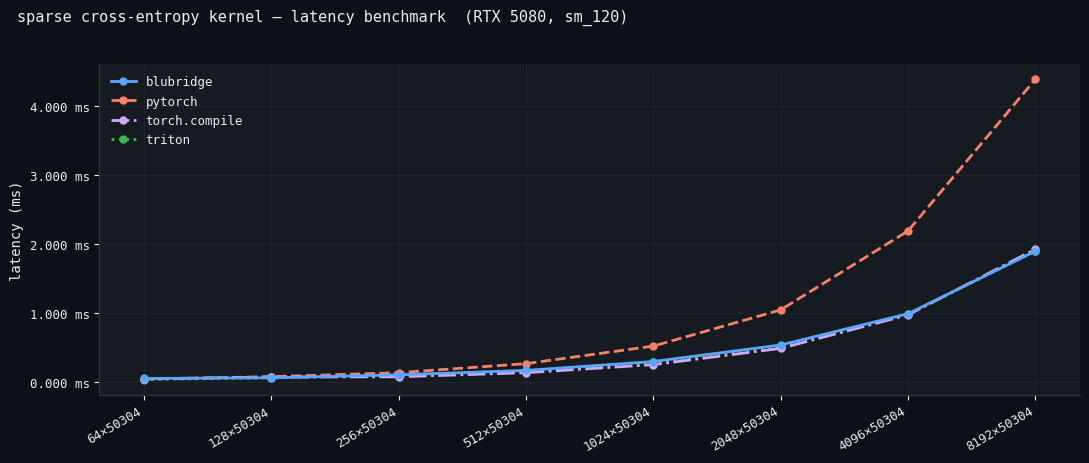

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Benchmark data (batch × vocab=50304, RTX 5080 sm_120) — latency in ms ─────
sizes = [
    '64×50304', '128×50304', '256×50304', '512×50304',
    '1024×50304', '2048×50304', '4096×50304', '8192×50304'
]

blubridge = [0.0512, 0.0614, 0.1044, 0.1679, 0.2970, 0.5366, 0.9892, 1.8941]
pytorch   = [0.0427, 0.0775, 0.1352, 0.2662, 0.5202, 1.0445, 2.1876, 4.3837]
compiled  = [0.0454, 0.0720, 0.0758, 0.1352, 0.2516, 0.4874, 0.9718, 1.9238]
triton    = [0.0365, 0.0594, 0.0983, 0.1638, 0.2843, 0.5199, 0.9830, 1.8954]

# ── Colors ────────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
TEXT   = '#e6edf3'
BLUE   = '#58a6ff'
ORANGE = '#f78166'
GREEN  = '#3fb950'
PURPLE = '#d2a8ff'

plt.rcParams.update({
    'font.family':        'monospace',
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        TEXT,
    'ytick.color':        TEXT,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#30363d',
    'axes.grid':          True,
    'grid.color':         '#ffffff',
    'grid.alpha':         0.06,
    'grid.linestyle':     '-',
    'grid.linewidth':     0.5,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
})

x = np.arange(len(sizes))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(x, blubridge, color=BLUE,   linewidth=2, marker='o', markersize=5,
        label='blubridge', zorder=4)
ax.plot(x, pytorch,   color=ORANGE, linewidth=2, marker='o', markersize=5,
        linestyle='--', label='pytorch', zorder=3)
ax.plot(x, compiled,  color=PURPLE, linewidth=2, marker='o', markersize=5,
        linestyle='-.', label='torch.compile', zorder=3)
ax.plot(x, triton,    color=GREEN,  linewidth=2, marker='o', markersize=5,
        linestyle=':', label='triton', zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latency (ms)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.3f} ms'))
ax.legend(fontsize=9, framealpha=0, loc='upper left', labelcolor=TEXT)
ax.tick_params(labelsize=9)

fig.suptitle('sparse cross-entropy kernel — latency benchmark  (RTX 5080, sm_120)',
             fontsize=11, fontweight='normal', y=1.02, x=0.02, ha='left',
             color=TEXT)

plt.tight_layout()
plt.savefig('benchmark.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()


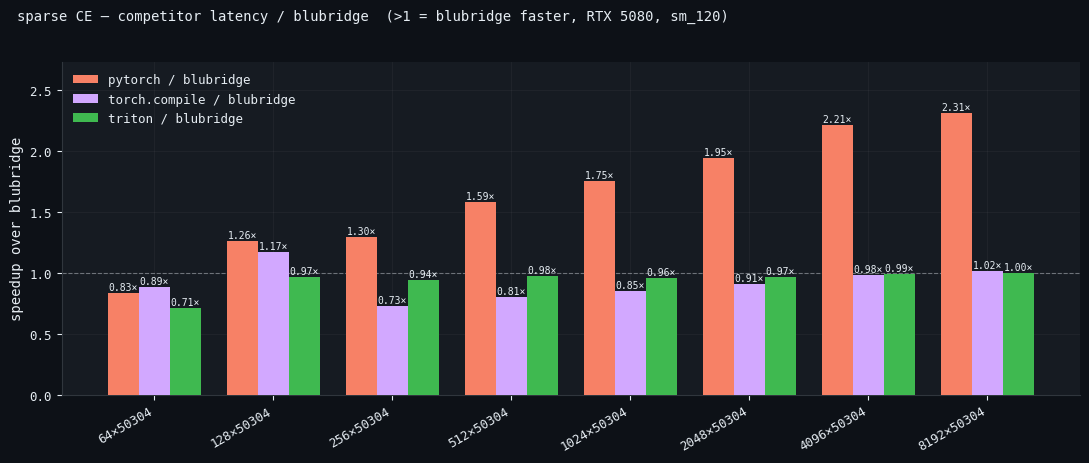

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Data ──────────────────────────────────────────────────────────────────────
sizes = [
    '64×50304', '128×50304', '256×50304', '512×50304',
    '1024×50304', '2048×50304', '4096×50304', '8192×50304'
]

blubridge = [0.0512, 0.0614, 0.1044, 0.1679, 0.2970, 0.5366, 0.9892, 1.8941]
pytorch   = [0.0427, 0.0775, 0.1352, 0.2662, 0.5202, 1.0445, 2.1876, 4.3837]
compiled  = [0.0454, 0.0720, 0.0758, 0.1352, 0.2516, 0.4874, 0.9718, 1.9238]
triton    = [0.0365, 0.0594, 0.0983, 0.1638, 0.2843, 0.5199, 0.9830, 1.8954]

# ── Speedup of competitors relative to blubridge (>1 = blubridge is faster) ──
sp_pytorch  = [pytorch[i]  / blubridge[i] for i in range(len(sizes))]
sp_compiled = [compiled[i] / blubridge[i] for i in range(len(sizes))]
sp_triton   = [triton[i]   / blubridge[i] for i in range(len(sizes))]

# ── Dark theme ────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
TEXT   = '#e6edf3'
ORANGE = '#f78166'
GREEN  = '#3fb950'
PURPLE = '#d2a8ff'

plt.rcParams.update({
    'font.family':        'monospace',
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        TEXT,
    'ytick.color':        TEXT,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.edgecolor':     '#30363d',
    'axes.grid':          True,
    'grid.color':         '#ffffff',
    'grid.alpha':         0.06,
    'grid.linestyle':     '-',
    'grid.linewidth':     0.5,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
})

n     = len(sizes)
x     = np.arange(n)
width = 0.26

fig, ax = plt.subplots(figsize=(11, 4.5))

b1 = ax.bar(x - width, sp_pytorch,  width, label='pytorch / blubridge',       color=ORANGE, zorder=3)
b2 = ax.bar(x,         sp_compiled, width, label='torch.compile / blubridge',  color=PURPLE, zorder=3)
b3 = ax.bar(x + width, sp_triton,   width, label='triton / blubridge',         color=GREEN,  zorder=3)

# 1× reference line — below this blubridge is slower
ax.axhline(1.0, color=TEXT, linewidth=0.8, linestyle='--', alpha=0.4)

# Value labels
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.008,
            f'{h:.2f}×',
            ha='center', va='bottom', fontsize=7, color=TEXT
        )

ax.set_xticks(x)
ax.set_xticklabels(sizes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('speedup over blubridge', fontsize=10)
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(labelsize=9)
ax.set_ylim(0, max(sp_pytorch + sp_compiled + sp_triton) * 1.18)

fig.suptitle('sparse CE — competitor latency / blubridge  (>1 = blubridge faster, RTX 5080, sm_120)',
             fontsize=10, fontweight='normal', y=1.02, x=0.02, ha='left', color=TEXT)

plt.tight_layout()
plt.savefig('benchmark_speedup.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
